In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

### `Q-1:` Using Gapminder Data
1. Create a scatter plot of 'gdpPercap' against 'lifeExp' for the year 2007, with the size of the markers determined by 'pop' and the color determined by 'continent'.

In [2]:
import plotly.express as px
df = px.data.gapminder()
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


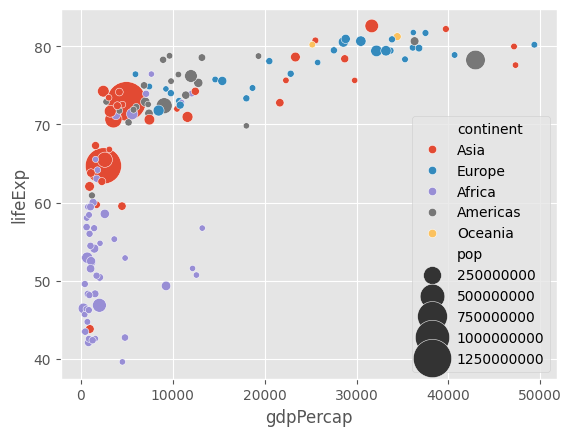

In [3]:
# Filter for 2007
df_2007 = df[df["year"] == 2007]

# Create plot
sns.scatterplot(
    data=df_2007,
    x="gdpPercap",
    y="lifeExp",
    hue="continent",
    size="pop",
    sizes=(20, 800),
)

plt.show()

### `Q-2-3:` Using `flights` dataset of seaborn.

2. Using the "flights" dataset that comes with seaborn, create a heatmap that shows the average number of passengers per month for each year.

3. Using the seaborn's flight dataset, create a clustermap to visualize the relationship between the number of passengers, months, and year.


In [4]:
df = sns.load_dataset('flights')
df.tail()

,year,month,passengers
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390
143,1960,Dec,432


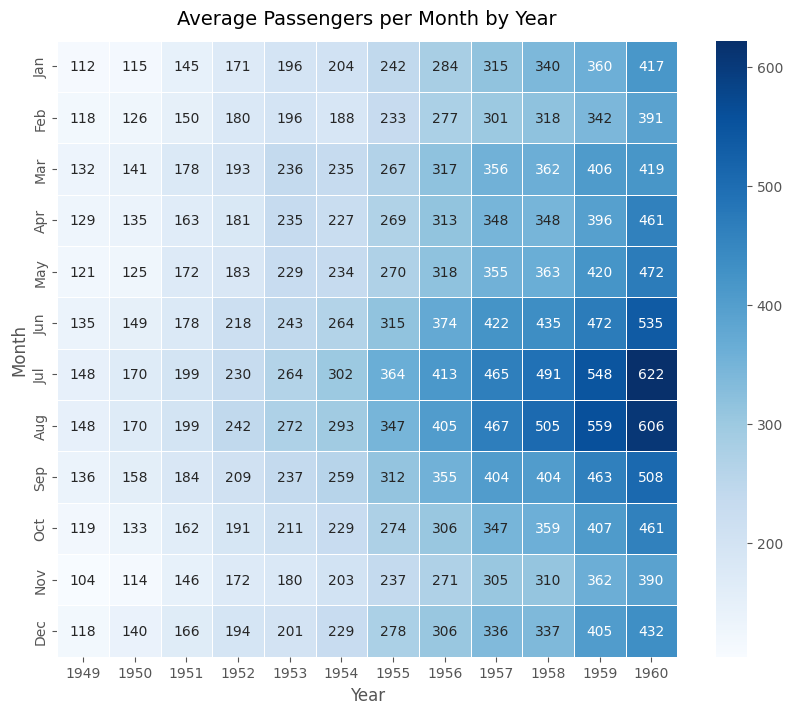

In [9]:
flights = sns.load_dataset("flights")
flights_pivot = flights.pivot(
    index="month", columns="year", values="passengers"
)

plt.figure(figsize=(10, 8))
sns.heatmap(flights_pivot, cmap="Blues", annot=True, fmt="d", linewidths=0.5)

plt.title("Average Passengers per Month by Year", fontsize=14, pad=12)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Month", fontsize=12)

plt.savefig("Plots/flights_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

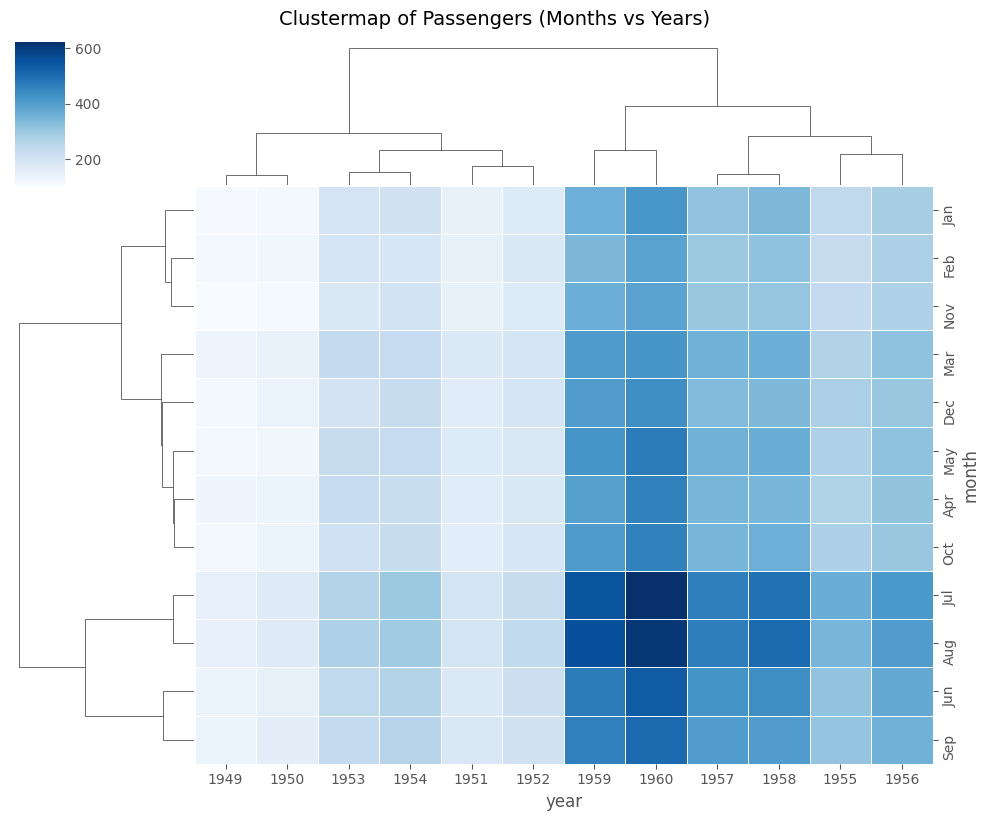

In [10]:
g = sns.clustermap(
    flights_pivot,
    cmap="Blues",
    col_cluster=True,
    row_cluster=True,
    linewidths=0.5,
    figsize=(10, 8),
)

g.fig.suptitle(
    "Clustermap of Passengers (Months vs Years)", fontsize=14, y=1.02
)

plt.savefig("Plots/flights_clustermap.png", bbox_inches="tight", dpi=150)
plt.show()

## For questions 4-8:

For these qestions, an insurance dataset is used. You can get details from [here](https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health). And if you want this dataset to use directly, then you can use this link: **https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/pub?gid=220677750&single=true&output=csv**

### **`Q-4:`** Draw a scatter plot based on the below conditions:
1. x-axis should be "age" and y-axis should be "bmi".
2. For hue, size and style parameters use "diabetic", "gender" and "smoker" column respectively.
3. Add title to your chart.
4. Age should be less than 70 percentiles.
5. BMI should be greater than the average value of the filtered age dataset.

In [11]:
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/pub?gid=220677750&single=true&output=csv')
df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


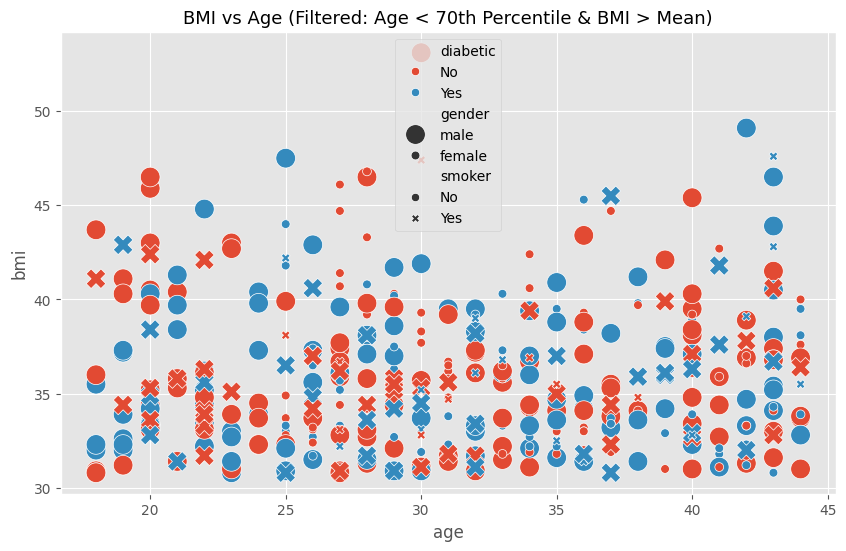

In [12]:
# 1. Filter dataset according to conditions (4 & 5)
age_limit = df["age"].quantile(0.70)
filtered_df = df[df["age"] < age_limit]

avg_bmi = filtered_df["bmi"].mean()
final_df = filtered_df[filtered_df["bmi"] > avg_bmi]

# 2. Plot scatter plot with conditions (1 & 2)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_df,
    x="age",
    y="bmi",
    hue="diabetic",
    size="gender",
    style="smoker",
    sizes=(40, 200),
)

# 3. Add title
plt.title(
    "BMI vs Age (Filtered: Age < 70th Percentile & BMI > Mean)", fontsize=13
)

# Save plot
plt.savefig("Plots/bmi_vs_age_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

### **`Q-5:`** Draw a line plot by using the below informations

1. bloodpressure vs children
2. Blood-pressure values should be between 90 and 100. The upper and lower limit are included.
3. Show the details of "smoker".

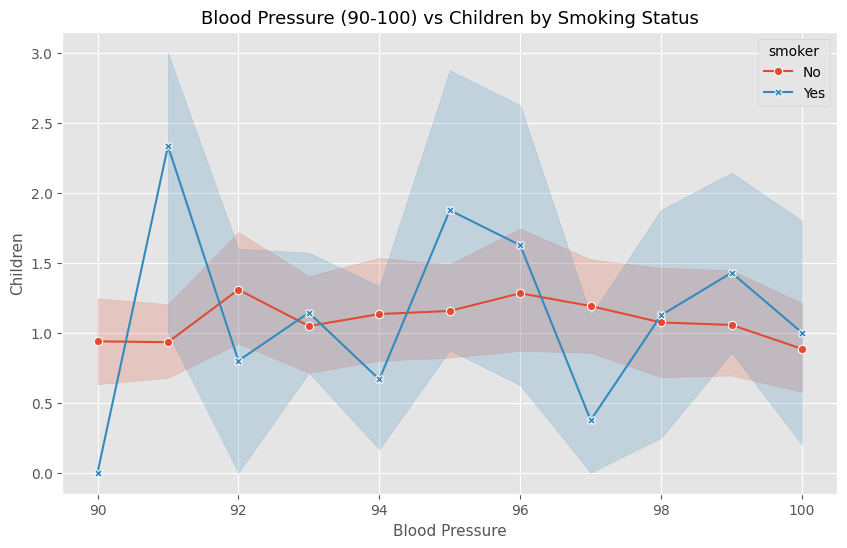

In [13]:
# Filter dataset for bloodpressure between 90 and 100 (inclusive)
filtered_df = df[(df["bloodpressure"] >= 90) & (df["bloodpressure"] <= 100)]

# Plot line plot: bloodpressure vs children with smoker details
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=filtered_df,
    x="bloodpressure",
    y="children",
    hue="smoker",
    style="smoker",
    markers=True,
    dashes=False,
)

plt.title(
    "Blood Pressure (90-100) vs Children by Smoking Status", fontsize=13
)
plt.xlabel("Blood Pressure", fontsize=11)
plt.ylabel("Children", fontsize=11)

plt.savefig("Plots/lineplot_bp_vs_children.png", bbox_inches="tight", dpi=150)
plt.show()

### **`Q-6:`** Draw a histogram using displot

- based on "age" column.
- Show details of "smoker" (hue).
- Create 2 separate charts for the above 2 conditions based on "gender" side-by-side.

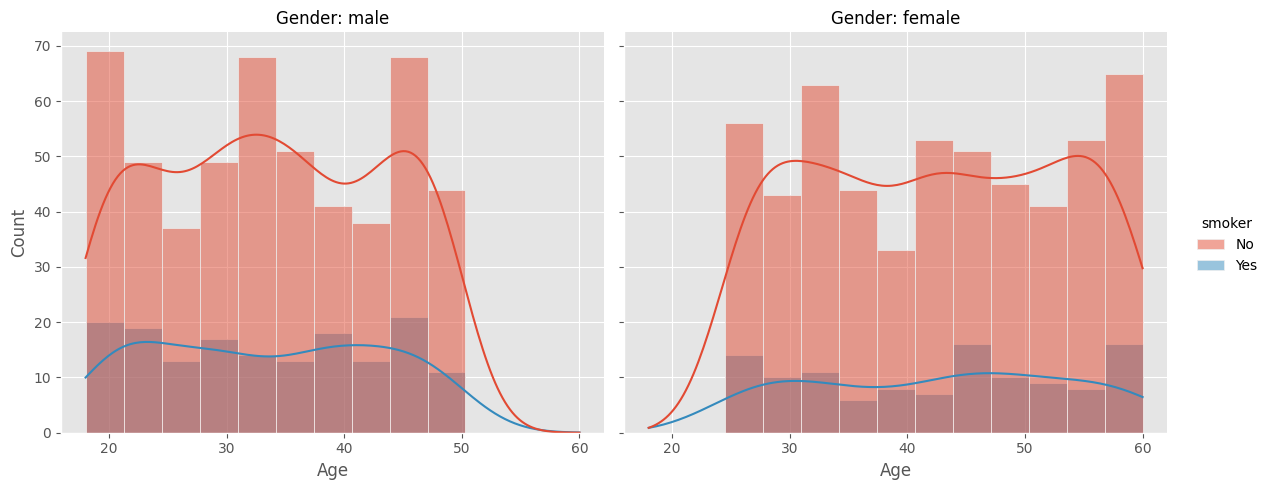

In [14]:
# Age distribution with smoker hue split by gender side-by-side
g = sns.displot(
    data=df,
    x="age",
    hue="smoker",
    col="gender",
    kind="hist",
    kde=True,
    height=5,
    aspect=1.2
)

g.set_axis_labels("Age", "Count")
g.set_titles(col_template="Gender: {col_name}")

plt.savefig("Plots/displot_age_gender_smoker.png", bbox_inches="tight", dpi=150)
plt.show()

### **`Q-7:`** Draw a kde plot between "age" and "bloodpressure".

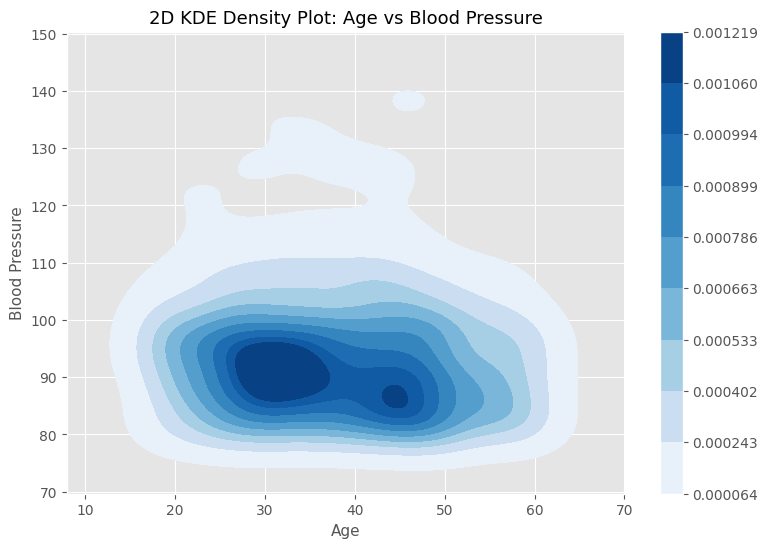

In [15]:
plt.figure(figsize=(9, 6))

sns.kdeplot(
    data=df,
    x="age",
    y="bloodpressure",
    fill=True,
    cmap="Blues",
    cbar=True
)

plt.title("2D KDE Density Plot: Age vs Blood Pressure", fontsize=13)
plt.xlabel("Age", fontsize=11)
plt.ylabel("Blood Pressure", fontsize=11)

plt.savefig("Plots/kde_age_vs_bloodpressure.png", bbox_inches="tight", dpi=150)
plt.show()

### **`Q-8:`** Draw a clustermap between between "age", "bmi" and "bloodpressure".

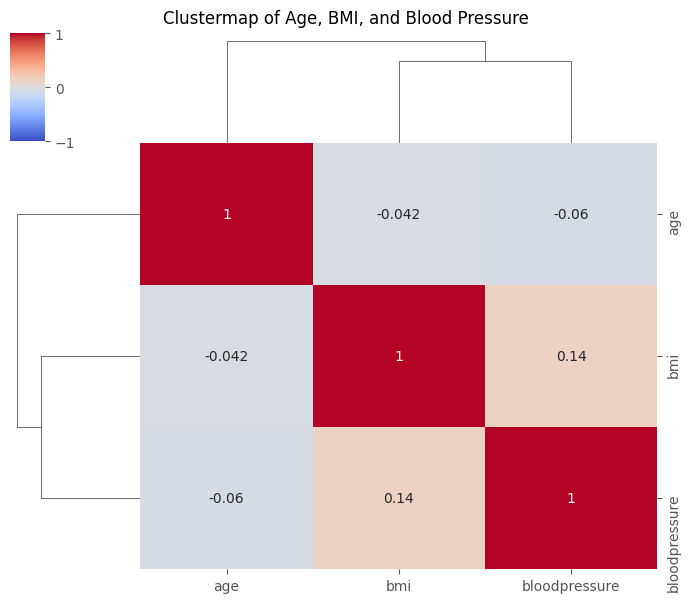

In [16]:
# Extract the relevant columns and calculate correlation matrix
selected_cols = df[["age", "bmi", "bloodpressure"]]
corr_matrix = selected_cols.corr()

# Draw the clustermap
g = sns.clustermap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    figsize=(7, 6)
)

g.fig.suptitle("Clustermap of Age, BMI, and Blood Pressure", y=1.02, fontsize=12)

plt.savefig("Plots/clustermap_age_bmi_bp.png", bbox_inches="tight", dpi=150)
plt.show()